In [ ]:
#make sure your terminal is in the same env as your nootbook
import sys
sys.executable


In [ ]:
#download needed packages
%pip install pandas numpy matplotlib seaborn 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 2.4 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 2.4 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [seaborn]m3/5 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Libraries imported successfully!


In [ ]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Verify it loaded by printing its shape (rows, col)
print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (303, 14)


In [ ]:
#.head() help you get a look at your data for extra info .info() is more suitable
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2,reversable,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0,normal,0


In [ ]:
# gives info on how large the dataset is , number of colums and each datas type 
# as well as info of null values of each col
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         303 non-null    int64  
 12  Thal       301 non-null    object 
 13  Target     303 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 33.3+ KB


In [ ]:
# 3. count of data, mean of the data, standard diviation of the data, min and max of data
# %25 under this value, %50 under this value, %75 under this
# can be usefull in understanding if we have skewed data from a specific col like for example sex we have way more man than women data

df.describe()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.686469,0.458746
std,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.947661,0.499120
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates 
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found.")

Number of duplicate rows: 0
No duplicates found.


Below is the part of my code where I check and delete a row that has data missing.

 The reason for choosing the deletion instead of guessing or avreaging the values is becasuse firsly it wouldnt be accurate it would still be a guess meaning that line of data is useless to me since the data has been tampered with if the data was about something like non critical then it would make sense but in health we should be using data that has been tampered with we should only used data that have been provided by real humans.
  If my dataset had been very small I would have took the AVG or Median but I dont think its usefull for me to do that in this senario.

In [51]:
# Check for missing values per column and display before and after
print("Before cleaning: ")
print()
print(df.isnull().sum())
df = df.dropna()
print()
print("After cleaning")
print()
print(df.isnull().sum())



Before cleaning: 

Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           0
Thal         0
Target       0
dtype: int64

After cleaning

Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           0
Thal         0
Target       0
dtype: int64


- Box plots, main rectangle is the middle %50 between 25-75 percentile. line is the median.
- is the data skewed or symmetrical, if the line is in the middle symmetrical if not its off-center close to the bottom positively skewed close to the top its negatively skewed. the dots that are outside the whiskers and the box plot are the outliers. since we are working on detecting heart disease it would be a bad idea for me to delete outliers deleting them would make my model blind to these patients.

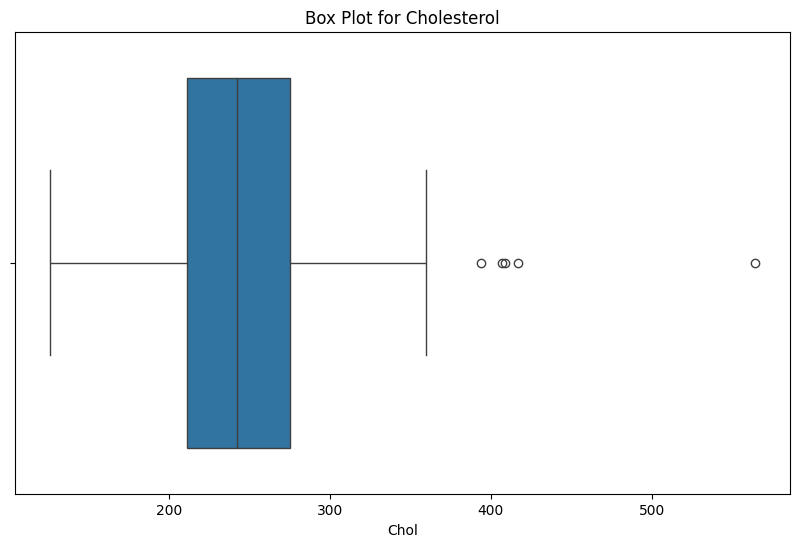

In [ ]:
# Set the figure size
plt.figure(figsize=(10, 6))

sns.boxplot(x=df['Chol']) 


plt.title('Box Plot for Cholesterol')
plt.show()

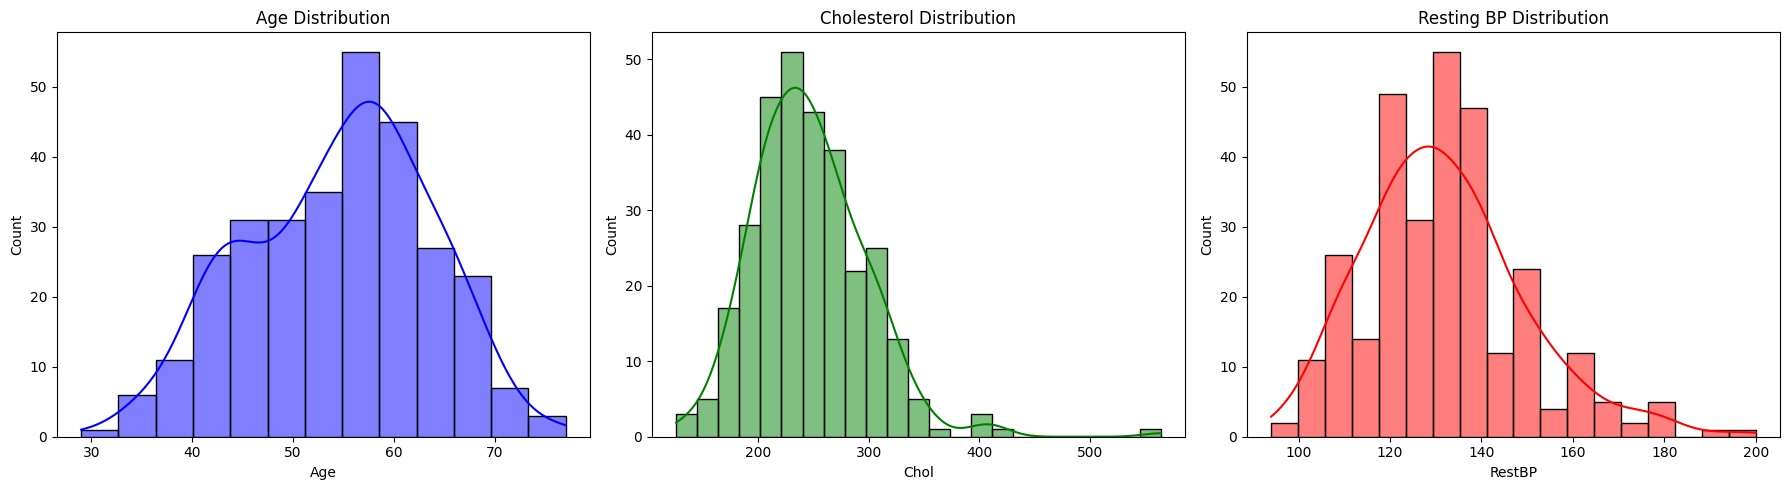

In [ ]:
# with a histogram I can visuialize if we have any skewed data to many old or young people etc
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Age Distribution')

# Cholesterol Distribution
sns.histplot(df['Chol'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Cholesterol Distribution')

# Resting Blood Pressure
sns.histplot(df[''], kde=True, ax=axes[2], color='red')
axes[2].set_title('Resting BP Distribution')

plt.tight_layout()
plt.show()

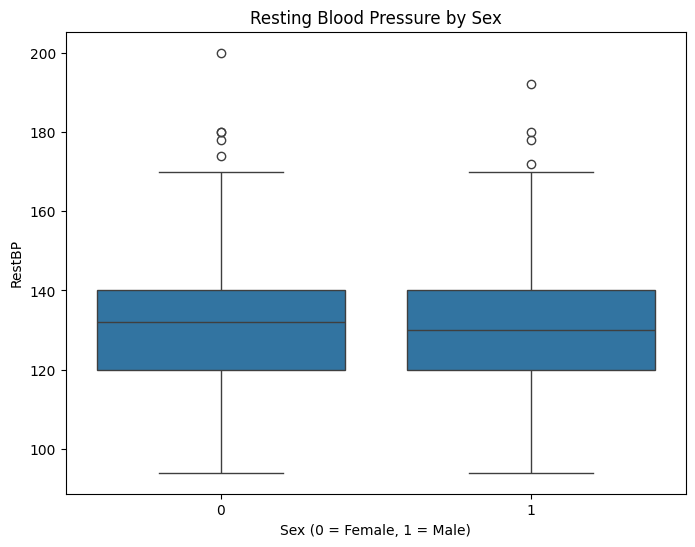

In [101]:
plt.figure(figsize=(8, 6))

sns.boxplot(x=df['Sex'], y=df['RestBP'])

plt.title('Resting Blood Pressure by Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.show()

we do see that the restingBP is a bit higher on AVG in females but I the difference is very minor that I would say with more data the gap would get even smaller I dont think we need to take it into account.

 dataset is very skewed to male patients data on female patients needs to be added for better results

# target distobution. the dataset seems to be fairly balanced though a bit skewed to healthly patients 


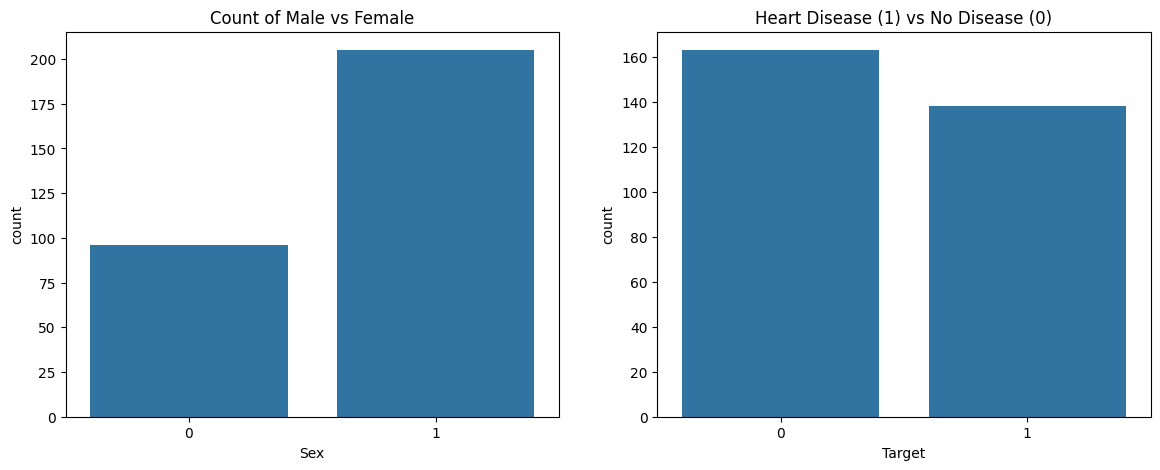

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex distrobution
sns.countplot(x=df['Sex'], ax=axes[0])
axes[0].set_title('Count of Male vs Female')

sns.countplot(x=df['Target'], ax=axes[1])
axes[1].set_title('Heart Disease (1) vs No Disease (0)')

plt.show()

with the chol and age dotted chart we can see that when age goes up so does the target rate while chol also does have an effect its not as much as age after seeing this I wanted to see if I a age and target rate line graph will it always go up or would we have a age gap where it would go down.

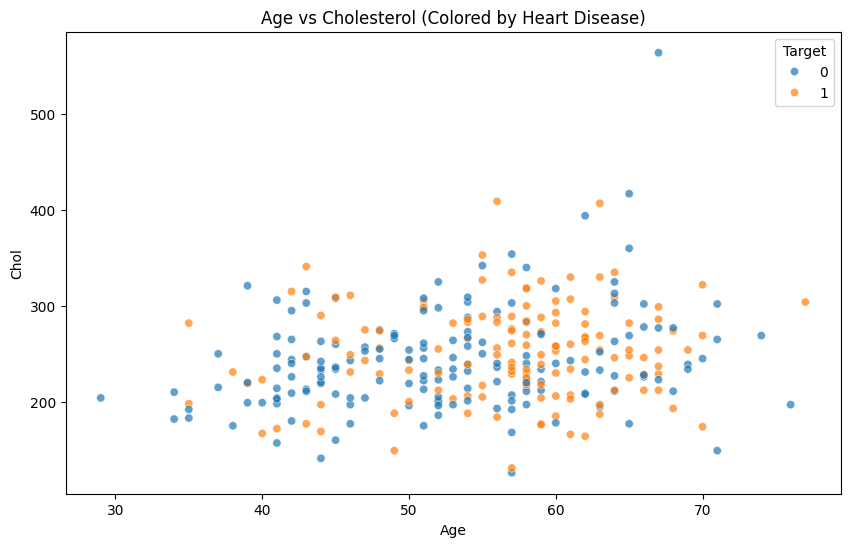

In [66]:
plt.figure(figsize=(10, 6))

# I added 'hue' here. This is a pro move.
# It colors the dots based on if they have heart disease.
# Now you are actually doing TRIVARIATE analysis (Age vs Chol vs Disease).
sns.scatterplot(x=df['Age'], y=df['Chol'], hue=df['Target'], alpha=0.7)

plt.title('Age vs Cholesterol (Colored by Heart Disease)')
plt.show()

with the line graph we can see that it does increase but not all the time I would say the increase isnt enough for me to take it as an important variable it could be usefull if I dont find anything with stronger corrolation. the linear deacrease between 60 to 70 is a bit weired but it could be that the data is a bit skewed in that direction.

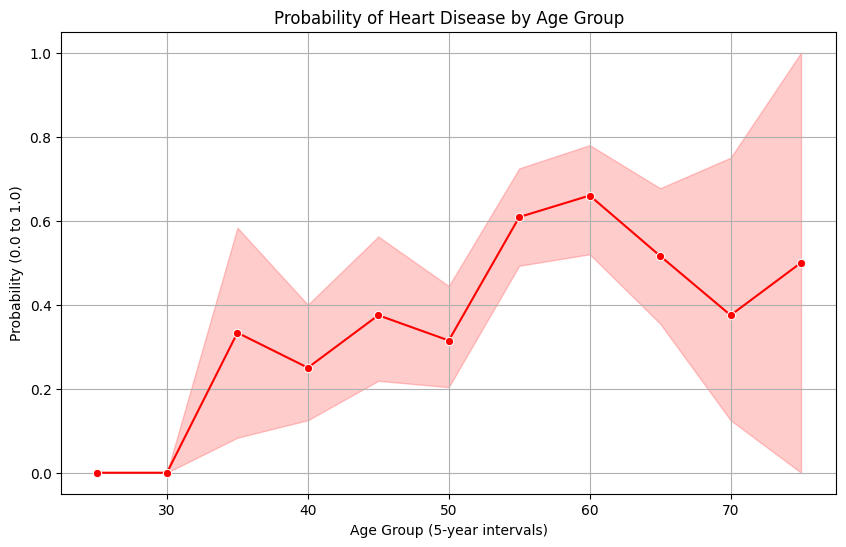

In [84]:
# 1. Create a new column for Age Groups (e.g., 30-35, 35-40)
# We use floor division // to group them
df['age_group'] = (df['Age'] // 5) * 5 

# 2. Create the line plot
plt.figure(figsize=(10, 6))

# distinct=False removes the confidence interval shadow if it's too messy
sns.lineplot(x='age_group', y='Target', data=df, marker='o', color='red')

plt.title('Probability of Heart Disease by Age Group')
plt.ylabel('Probability (0.0 to 1.0)')
plt.xlabel('Age Group (5-year intervals)')
plt.grid(True)
plt.show()

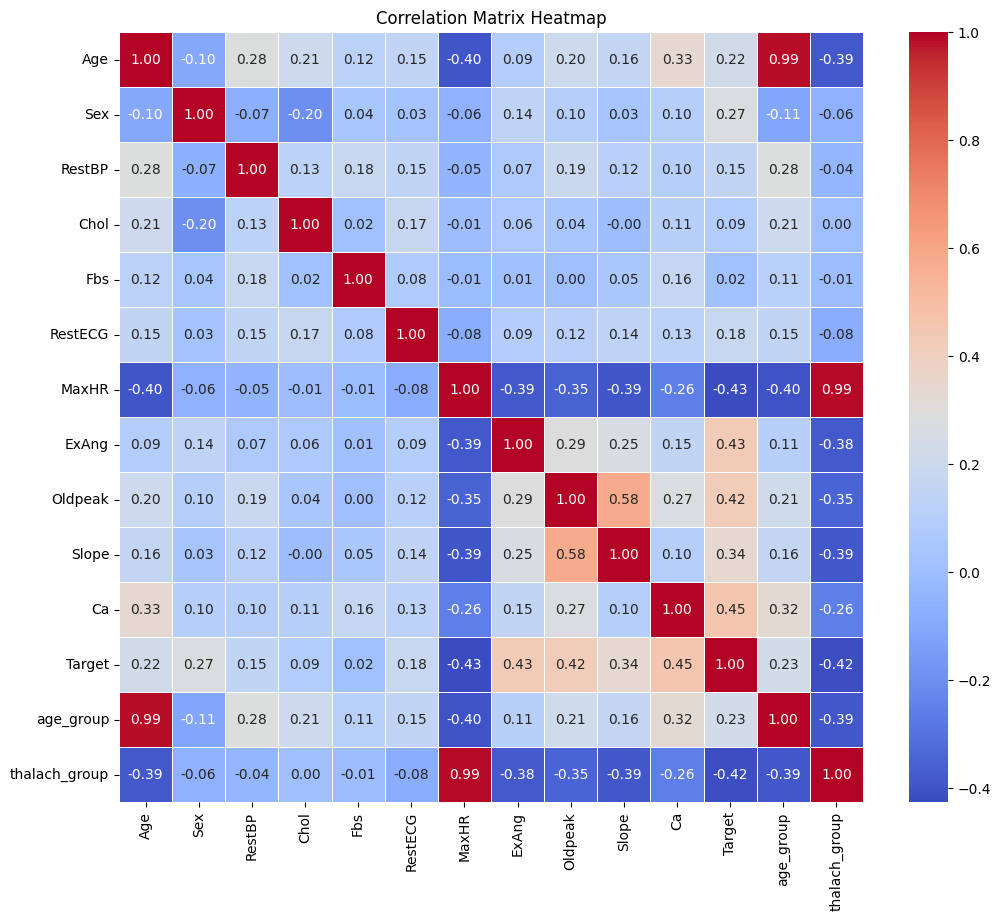

In [90]:
  # Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()



After using a heatMap we can see which variables effect the target rate the most maxHR,Ca, oldPeak, ExAng, the other variables dont have that high of corralation. but since the heatMap normally dosent acount for object/string type data I used One-Hot incoding to add them to the heatMap(I also added 2 features to be able to draw a line graph age_group and maxHR group)

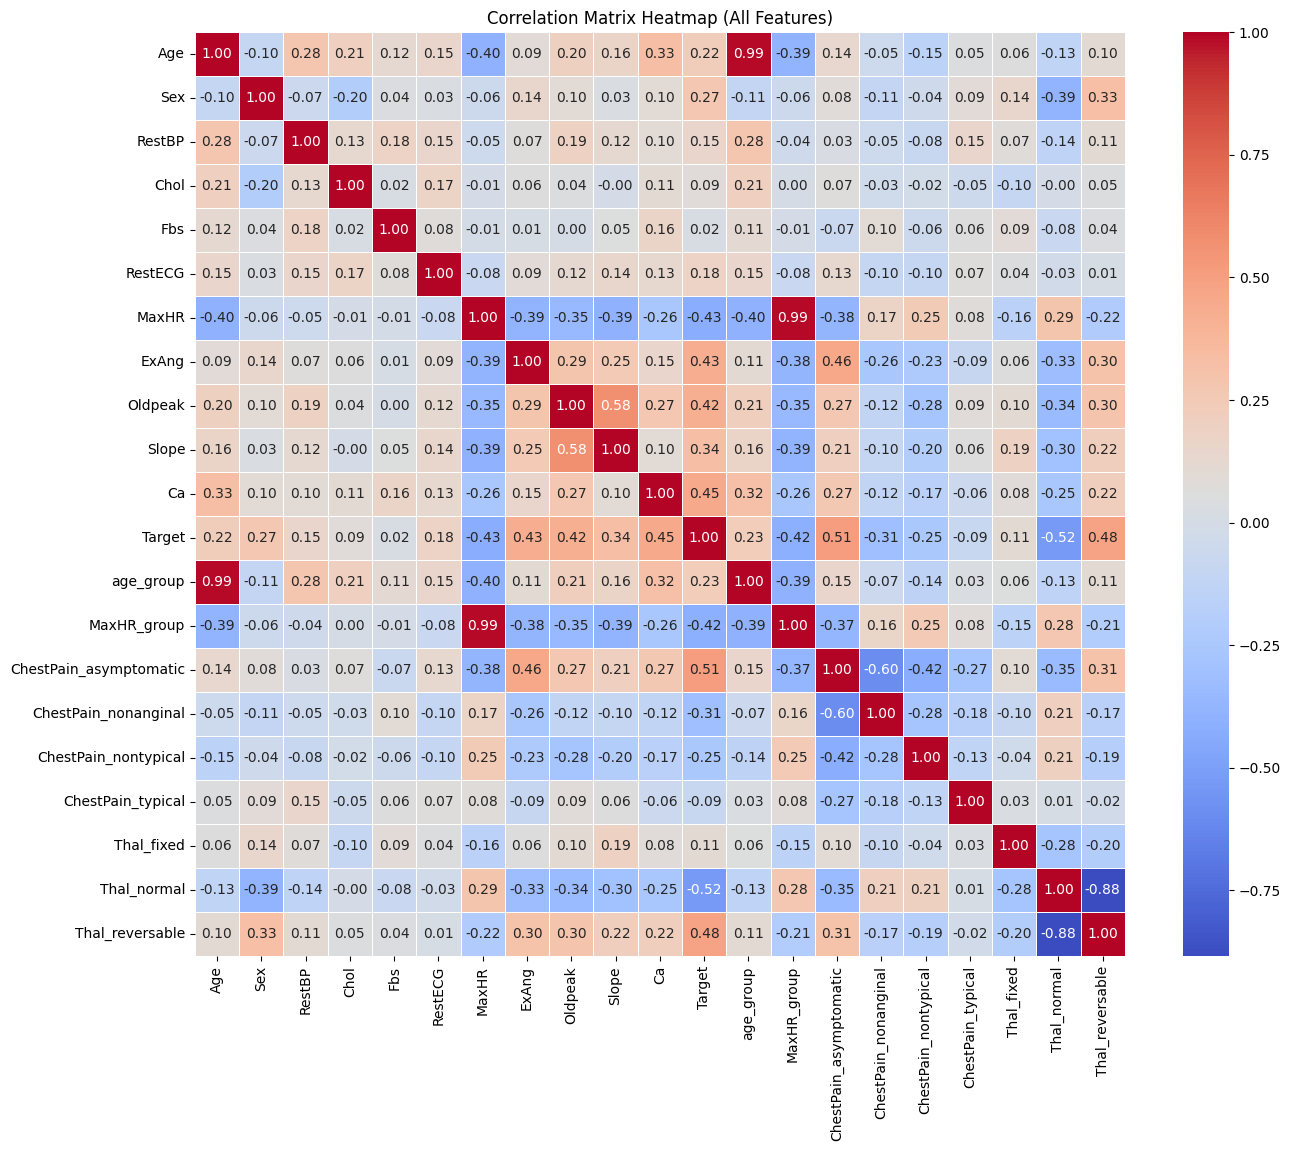

In [103]:

# One-Hot Encode categorical columns
df_encoded = pd.get_dummies(df, columns=['ChestPain', 'Thal'], drop_first=False)

# Calculate correlation
corr_matrix = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap (All Features)')
plt.show()


after adding the object data we can see that thal has an even larger corroletion than the other variables reversable has a 0.48 positive while not having one(normal) has a negative 0.52.

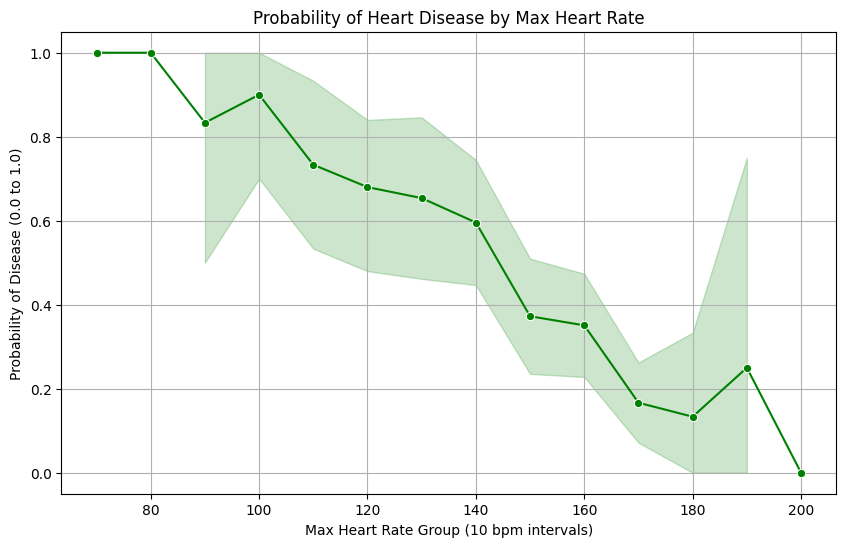

In [ ]:
# Create a new column for Max HR Groups
df['MaxHR_group'] = (df['MaxHR'] // 10) * 10 

# Create the line plot
plt.figure(figsize=(10, 6))

# Plotting Max HR Group vs. Probability of Heart Disease
sns.lineplot(x='MaxHR_group', y='Target', data=df, marker='o', color='green')

plt.title('Probability of Heart Disease by Max Heart Rate')
plt.ylabel('Probability of Disease (0.0 to 1.0)')
plt.xlabel('Max Heart Rate Group (10 bpm intervals)')
plt.grid(True)
plt.show()

My last thoughts are as follows:
the most corrolated variables are these in order: thal-Normal(-0.52), thal-reversed(0.48), Ca(0.45), ExAng(0.43) and lastly MaxHr(-0.43). there are some in the 0.3 ranges but I would say those are a bit to low for us to take them into account. also looking at the heatMaps we can see that some variables have almost no corrolation between the target rate. In summary I would say these 5 are the most important features mainly the thal reverse and normal corrolation those are the highest.